Formulas:
$$
\begin{align*}
FOV &= \frac{S_{sensor}}{M}\\
DOF &= \frac{\lambda\cdot n}{NA^2}+\frac{e\cdot n}{M\cdot NA}\\
Res &= \frac{\lambda}{2 \, NA}\\
M &= \frac{f_{img}}{f_{obj}}\\
NA_{obj} &= nsin(\theta)=nsin(arctan(\frac{D}{2f}))
\end{align*}
$$
Parameters:
$$
n = 1,\qquad
e = 8.5 \mu m,\qquad
\lambda = 850 nm,\qquad f_{obj},\qquad f_{img}
$$

0.006604800000000001
0.03866719139446412 0.003029585798816568


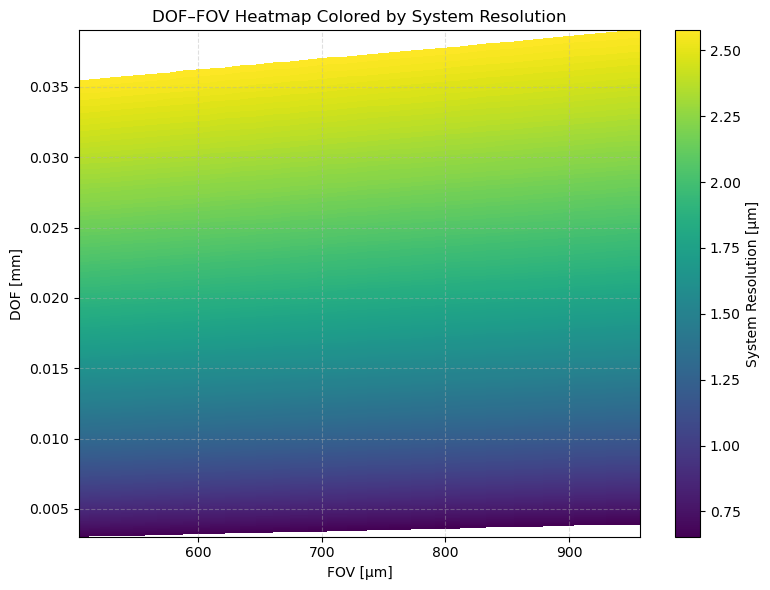

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---- functions ----
def FOV(sensor_size, M):
    """Field of View (object space) in meters (H direction)."""
    return sensor_size / M

def DOF(lmbd, n, NA, e, M):
    """
    Depth of Field (diffraction + pixel term), full formula.
    lmbd: wavelength [m]
    n: refractive index
    NA: numerical aperture
    e: pixel size [m]
    M: total magnification
    Returns DOF in meters
    """
    term1 = lmbd * n / (NA ** 2)        # diffraction term
    term2 = e * n / (M * NA)            # pixel term
    return term1 + term2

def SystemResolution(lambda_, NA, e, M):
    """System-limited resolution considering diffraction and pixel sampling."""
    R_optical = lambda_ / (2 * NA)      # diffraction-limited resolution
    R_pixel = e / M                     # pixel-limited resolution
    return R_optical

# ---- camera parameters (CCIR) ----
pixel_size_H = 8.6e-6  # horizontal pixel size [m]
num_pixels_H = 768     # horizontal effective pixels
sensor_width = pixel_size_H * num_pixels_H   # [m]
print(sensor_width)

# ---- optical parameters ----
lambda_ = 850e-9  # wavelength [m]
n = 1
e = pixel_size_H

# ---- NA and M values ----
# filter ranges
NA_min, NA_max = 0.165, 0.65
M_min,  M_max  = 7, 13

NA_vals = np.linspace(NA_min,NA_max,400)

#f_obj_min, f_obj_max = 0.02, 0.20
#M_vals = np.linspace(Magnification(f_obj_max,f_img), Magnification(f_obj_min,f_img), 300)
M_vals = np.linspace(M_min, M_max,30)
FOV_vals = FOV(sensor_width, M_vals) * 1e6  # µm

# ---- compute grid ----
FOV_grid = np.zeros((len(NA_vals), len(M_vals)))
DOF_grid = np.zeros_like(FOV_grid)
Res_grid = np.zeros_like(FOV_grid)

for i, NA in enumerate(NA_vals):
    SysRes_vals = np.array([SystemResolution(lambda_, NA, e, M) for M in M_vals]) * 1e6  # µm
    DOF_vals = np.array([DOF(lambda_, n, NA, e, M) for M in M_vals]) * 1e3               # mm

    FOV_grid[i, :] = FOV_vals
    DOF_grid[i, :] = DOF_vals
    Res_grid[i, :] = SysRes_vals

print(np.max(DOF_grid), np.min(DOF_grid))
# ---- create heatmap ----
fig, ax = plt.subplots(figsize=(8,6))

# heatmap: X axis = FOV, Y axis = DOF, Color = Resolution
heatmap = ax.pcolormesh(FOV_grid, DOF_grid, Res_grid, cmap='viridis', shading='auto')

# colorbar
cbar = plt.colorbar(heatmap, ax=ax)
cbar.set_label("System Resolution [µm]")

ax.set_xlabel("FOV [µm]")
ax.set_ylabel("DOF [mm]")
ax.set_title("DOF–FOV Heatmap Colored by System Resolution")

ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [5]:
import math
import numpy as np

def numerical_aperture(D, f, n=1):
    """Compute NA for circular aperture."""
    return n * D / math.sqrt(4 * f * f + D * D)

def Magnification(f_obj, f_img):
    """Magnification for 4f system."""
    return f_img / f_obj

# aperture
D = 25.4e-3   # [m]

# focal length list (in meters)
f_list = [ 0.015, 0.0201, 0.025, 0.0301, 0.035, 0.0401, 0.0502, 0.060, 0.0753, 0.1004, 0.125, 0.1499, 0.175, 0.200, 0.250, 0.300, 0.350, 0.400, 0.4499, 0.500, 0.600, 0.750, 0.850 ]

print(f"{'f_obj(mm)':<10} {'f_img(mm)':<10} {'NA':<8} {'M':<8} {'FOV(um)':<10} {'DOF(mm)':<12} {'Res(um)':<10}")
print("-"*80)
NA_list=[]
M_list=[]

for f_img in f_list:
    for f_obj in f_list:
        NA = numerical_aperture(D, f_obj)
        M = Magnification(f_obj, f_img)
        NA_list.append(NA)
        M_list.append(M)    

        
        fov_val = FOV(sensor_width, M) * 1e6       # um
        dof_val = DOF(lambda_, n, NA, e, M) * 1e3  # mm
        res_val = SystemResolution(lambda_, NA, e, M) * 1e6  # um

        if NA_min <= NA <= NA_max and M_min <= M <= M_max and dof_val>=0.01:
        #if dof_val>=.015 and M>=8:
        #if M_min <= M <= M_max and fov_val<=1500 and f_img<=0.4:
            print(f"{f_obj*1000:<10.1f} {f_img*1000:<10.1f} {NA:<8.4f} {M:<8.2f} {fov_val:<10.2f} {dof_val:<12.5f} {res_val:<10.2f}")
print(f"NA range: {NA_min:.3f}  →  {NA_max:.3f}")
print(f"M  range: {M_min:.1f}   →  {M_max:.1f}")
#print(max(NA_list),min(NA_list))
#print(max(M_list),min(M_list))


f_obj(mm)  f_img(mm)  NA       M        FOV(um)    DOF(mm)      Res(um)   
--------------------------------------------------------------------------------
35.0       250.0      0.3411   7.14     924.67     0.01084      1.25      
35.0       300.0      0.3411   8.57     770.56     0.01025      1.25      
40.1       300.0      0.3019   7.48     882.84     0.01313      1.41      
40.1       350.0      0.3019   8.73     756.72     0.01259      1.41      
40.1       400.0      0.3019   9.98     662.13     0.01218      1.41      
50.2       400.0      0.2453   7.97     828.90     0.01853      1.73      
40.1       449.9      0.3019   11.22    588.69     0.01186      1.41      
50.2       449.9      0.2453   8.96     736.97     0.01804      1.73      
60.0       449.9      0.2071   7.50     880.84     0.02536      2.05      
40.1       500.0      0.3019   12.47    529.70     0.01161      1.41      
50.2       500.0      0.2453   9.96     663.12     0.01765      1.73      
60.0       500.0   

In [6]:
print(f"{'f_obj(mm)':<10} {'f_img(mm)':<10} {'NA':<8} {'M':<8} {'FOV(um)':<10} {'DOF(mm)':<12} {'Res(um)':<10}")
print("-"*80)
fi_test=[ 0.250]
fo_test=[0.025, 0.0301, 0.035, 0.0401, 0.0502, 0.060, 0.0753]
for f_img in fi_test:
    for f_obj in fo_test:
      NA = numerical_aperture(D, f_obj)
      M  = Magnification(f_obj, f_img)
      FOV_val = FOV(sensor_width, M) * 1e6          # m → µm
      DOF_val = DOF(lambda_, n, NA, e, M) * 1e3     # m → mm
      RES_val = SystemResolution(lambda_, NA, e, M) * 1e6  # m → µm
      #if DOF_val>=0.02:
      print(f"{f_obj*1000:<10.1f} {f_img*1000:<10.1f} {NA:<8.4f} {M:<8.2f} "
            f"{FOV_val:<10.2f} {DOF_val:<12.3f} {RES_val:<10.2f}")

f_obj(mm)  f_img(mm)  NA       M        FOV(um)    DOF(mm)      Res(um)   
--------------------------------------------------------------------------------
25.0       250.0      0.4529   10.00    660.48     0.006        0.94      
30.1       250.0      0.3887   8.31     795.22     0.008        1.09      
35.0       250.0      0.3411   7.14     924.67     0.011        1.25      
40.1       250.0      0.3019   6.23     1059.41    0.014        1.41      
50.2       250.0      0.2453   4.98     1326.24    0.021        1.73      
60.0       250.0      0.2071   4.17     1585.15    0.030        2.05      
75.3       250.0      0.1663   3.32     1989.37    0.046        2.56      
